# PHY241 Group Project V - Particle Discovery Experiment
### Sandrin Hunkeler, Elisabeth Giryes, Manasi Tiwari

We want to discover a 5 GeV meson decaying to two muons. The plan:
1. **Define a selection** using a BDT to separate signal from background
2. **Determine how long** we need to run the experiment for a 5 sigma discovery

The 10k signal and 10k background samples are Monte Carlo simulations, not real data. We know which is which because we generated them. We use them to train our classifiers and measure how well the selection works. In reality the experiment would only see about 50 signal events per year mixed into 2000 background events. So the plan is: develop a good selection on the large MC samples (Part 1), then apply those efficiencies to the realistic scenario and figure out how long we need to run (Part 2).

### Setup
#### Imports

In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize
from scipy.stats import norm
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'font.size': 10,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
})


#### Constants

Experiment parameters in one place. `SEED` controls every stochastic step (BDT splits and the toy MC blocks below).

In [3]:
# experiment-wide constants
SEED = 42

# signal model
MU = 5.0
SIGMA = 0.03

# analysis mass window
MASS_LO = 4.0
MASS_HI = 6.0

# yearly event rates before selection
N_SIG_PER_YEAR = 50
N_BKG_PER_YEAR = 2000

#### Load Data

In [4]:
os.makedirs('plots', exist_ok=True)

# load data using pandas, separated by whitespace
sig = pd.read_csv('data/signal_Bs2MuMu.txt', sep=r'\s+')
bkg = pd.read_csv('data/background_combinatorial.txt', sep=r'\s+')

# print number of events and columns in each dataset
print(f"Signal events: {len(sig)}, Background events: {len(bkg)}")
print(f"Columns: {list(sig.columns)}")
sig.head()

Signal events: 10000, Background events: 10000
Columns: ['Mu1_PT', 'Mu2_PT', 'Mu1_P', 'Mu2_P', 'tot_PT', 'VTXCHI2', 'ISO', 'MASS']


,Mu1_PT,Mu2_PT,Mu1_P,Mu2_P,tot_PT,VTXCHI2,ISO,MASS
0,0.504884,10.047968,108.678309,418.772201,9.948355,10.900830,-0.267760,5.431576
1,2.376916,2.867787,3.259937,5.758319,0.597111,7.726661,-0.091041,5.369218
2,2.745118,2.083754,21.563601,5.886996,1.141887,5.365485,0.426770,5.385961
3,2.456457,3.258238,36.856714,40.732084,2.099610,5.385230,-0.097810,5.344424
4,4.603657,3.143709,53.196382,10.199124,7.669011,3.700915,0.354561,5.389953


## Part 1: Define Selection (Section 3)

### 1a - Feature histograms

Let's look at all 8 features and see which ones separate signal from background best.

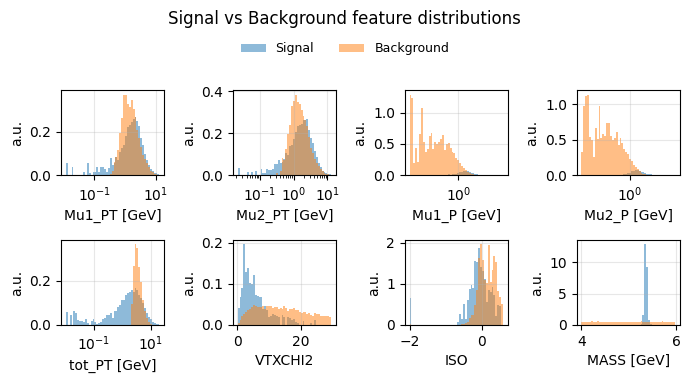

In [5]:
# define features and units for plotting
features = sig.columns.tolist()

units = {
    'Mu1_PT': '[GeV]', 'Mu2_PT': '[GeV]',
    'Mu1_P': '[GeV]', 'Mu2_P': '[GeV]',
    'tot_PT': '[GeV]', 'VTXCHI2': '',
    'ISO': '', 'MASS': '[GeV]',
}

# momentum features are very skewed, so use log x-axis for easier visualization
log_x_features = ['Mu1_PT', 'Mu2_PT', 'Mu1_P', 'Mu2_P', 'tot_PT']
# plot histograms of each feature for signal and background
fig, axes = plt.subplots(2, 4, figsize=(7, 3.5))
# flatten axes for easy indexing
axes = axes.flatten()

# loop over features and plot histograms
for i, feat in enumerate(features):
    ax = axes[i]
    use_log_x = feat in log_x_features

    # determine bin edges based on combined signal and background distributions
    # use log-spaced bins for skewed features, linear bins otherwise
    if use_log_x:
        lo = max(min(sig[feat].min(), bkg[feat].min()), 1e-3)
        hi = max(sig[feat].quantile(0.99), bkg[feat].quantile(0.99))
        bins = np.logspace(np.log10(lo), np.log10(hi), 50)
    else:
        lo = min(sig[feat].min(), bkg[feat].min())
        hi = max(sig[feat].quantile(0.99), bkg[feat].quantile(0.99))
        bins = np.linspace(lo, hi, 50)

    # plot histograms for signal and background
    ax.hist(sig[feat], bins=bins, density=True, histtype='stepfilled',
            alpha=0.5, label='Signal')
    ax.hist(bkg[feat], bins=bins, density=True, histtype='stepfilled',
            alpha=0.5, label='Background')

    # set log scale if needed
    if use_log_x:
        ax.set_xscale('log')

    # set axis labels
    unit = units.get(feat, '')
    ax.set_xlabel(f'{feat} {unit}'.strip())
    ax.set_ylabel('a.u.')
    ax.grid(True, alpha=0.3)

# shared legend across the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False,
           bbox_to_anchor=(0.5, 1.02))
plt.suptitle('Signal vs Background feature distributions', y=1.08)
plt.tight_layout()
plt.savefig('plots/feature_histograms.png', dpi=200, bbox_inches='tight')
plt.show()


From the histograms we can see that `VTXCHI2` and `ISO` show clear separation between signal and background. `MASS` also separates well, but **we can't use MASS in the BDT** because that would sculpt the mass distribution and bias the fit in Part 2.

### 1b - Fisher scores

The Fisher score quantifies how well a single feature separates two classes:

$$F = \frac{(\mu_s - \mu_b)^2}{\sigma_s^2 + \sigma_b^2}$$

Feature  Fisher Score
VTXCHI2      0.803660
   MASS      0.425375
    ISO      0.258816
  Mu2_P      0.068572
  Mu1_P      0.067968
 tot_PT      0.041046
 Mu1_PT      0.031375
 Mu2_PT      0.028887


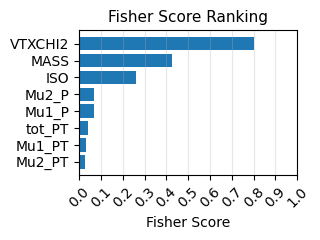


Top 3 features (excluding MASS): ['VTXCHI2', 'ISO', 'Mu2_P']


In [6]:
# compute Fisher score for each feature
fisher_scores = {}
# iterate over features and compute Fisher score using mean and variance of signal and background
for feat in features:
    mu_s, mu_b = sig[feat].mean(), bkg[feat].mean()
    var_s, var_b = sig[feat].var(), bkg[feat].var()
    # fisher score is (mu_s - mu_b)^2 / (var_s + var_b)
    fisher_scores[feat] = (mu_s - mu_b)**2 / (var_s + var_b)

# put scores in a DataFrame and sort
fisher_df = pd.DataFrame({
    'Feature': list(fisher_scores.keys()),
    'Fisher Score': list(fisher_scores.values())
})
fisher_df = fisher_df.sort_values('Fisher Score', ascending=False).reset_index(drop=True)

# print the table of Fisher scores
print(fisher_df.to_string(index=False))

# plot the Fisher scores as a horizontal bar chart
fig, ax = plt.subplots(figsize=(3.3, 2.5))
ax.barh(fisher_df['Feature'], fisher_df['Fisher Score'])
ax.set_xlabel('Fisher Score')
ax.set_title('Fisher Score Ranking')
ax.invert_yaxis() # highest score on top
ax.grid(True, alpha=0.3, axis='x')
# ticks every 0.1, rotated for readability
ax.set_xticks(np.arange(0, 1 + 0.1, 0.1))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('plots/fisher_scores.png', dpi=200, bbox_inches='tight')
plt.show()

# top 3 features (excluding MASS)
bdt_features_3 = [f for f in fisher_df['Feature'] if f != 'MASS'][:3]
print(f"\nTop 3 features (excluding MASS): {bdt_features_3}")

### 1c - Rectangular cuts (top 3 features)

For each of the top 3 features we scan thresholds and pick the direction (above/below) that gives the best accuracy. Events must pass all 3 cuts at the same time.

In [7]:
# create labels for signal and background
y_sig = np.ones(len(sig)) # signal labeled as 1
y_bkg = np.zeros(len(bkg)) # background labeled as 0
y_all = np.concatenate([y_sig, y_bkg]) # combined labels for all data

def find_best_cut(signal_values, background_values):
    """Find the best rectangular cut on a single feature to separate signal and background."""
    # scan thresholds and try both cut directions
    all_values = np.concatenate([signal_values, background_values])
    thresholds = np.linspace(np.percentile(all_values, 1), np.percentile(all_values, 99), 200)

    # loop over thresholds and compute accuracy for both cut directions
    best_accuracy, best_threshold, best_direction = 0, 0, '>'
    # for each threshold, compute true positives and true negatives for both cut directions
    for threshold in thresholds:
        tp_gt = np.sum(signal_values > threshold)
        tn_gt = np.sum(background_values <= threshold)
        acc_gt = (tp_gt + tn_gt) / (len(signal_values) + len(background_values))

        tp_lt = np.sum(signal_values < threshold)
        tn_lt = np.sum(background_values >= threshold)
        acc_lt = (tp_lt + tn_lt) / (len(signal_values) + len(background_values))

        if acc_gt > best_accuracy:
            best_accuracy, best_threshold, best_direction = acc_gt, threshold, '>'
        if acc_lt > best_accuracy:
            best_accuracy, best_threshold, best_direction = acc_lt, threshold, '<'
    # return the best threshold, direction, and accuracy
    return best_threshold, best_direction, best_accuracy

# find the best cut for each of the top 3 features and store it
cuts = {}
for feature_name in bdt_features_3:
    best_threshold, best_direction, best_accuracy = find_best_cut(sig[feature_name].values, bkg[feature_name].values)
    cuts[feature_name] = (best_threshold, best_direction)
    print(f"{feature_name}: cut {best_direction} {best_threshold:.4f}, accuracy = {best_accuracy:.4f}")

# apply all 3 cuts together
sig_pass = np.ones(len(sig), dtype=bool) # start with all signal events passing
bkg_pass = np.ones(len(bkg), dtype=bool) # start with all background events passing

# combine the cuts by applying them sequentially to signal and background
for feature_name, (threshold, direction) in cuts.items():
    if direction == '>':
        # for a "feature > threshold" cut, an event passes if its feature value is above the threshold
        sig_pass = sig_pass & (sig[feature_name].values > threshold)
        bkg_pass = bkg_pass & (bkg[feature_name].values > threshold)
    else:
        # for a "feature < threshold" cut, an event passes if its feature value is below the threshold
        sig_pass = sig_pass & (sig[feature_name].values < threshold)
        bkg_pass = bkg_pass & (bkg[feature_name].values < threshold)

# combined accuracy, signal efficiency, and background rejection for the rectangular cuts
rect_acc = (np.sum(sig_pass) + np.sum(~bkg_pass)) / (len(sig) + len(bkg))
print(f"\nCombined rectangular cut accuracy: {rect_acc:.4f}")
print(f"Signal eff: {np.mean(sig_pass):.4f}, Bkg rejection: {1 - np.mean(bkg_pass):.4f}")


VTXCHI2: cut < 7.8676, accuracy = 0.7498
ISO: cut < -0.0864, accuracy = 0.6720
Mu2_P: cut > 4.7525, accuracy = 0.7654

Combined rectangular cut accuracy: 0.6352
Signal eff: 0.2814, Bkg rejection: 0.9891


### 1d - BDT with 3 features

Now we train a Boosted Decision Tree (BDT), specifically a Gradient Boosting classifier, on the same 3 features. The BDT should do better than rectangular cuts since it can capture non-linear boundaries between signal and background. We split the data 50/50 into train and test sets so we can check for overfitting.

In [8]:
# combine signal and background and create labels for the BDT
X_all = pd.concat([sig, bkg], ignore_index=True)
y_all = np.concatenate([np.ones(len(sig)), np.zeros(len(bkg))])

# 50/50 train/test split to avoid overfitting bias
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.5, random_state=SEED
)

# train a BDT on the top 3 features (200 trees, depth 3, learning rate 0.1)
bdt_3 = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=SEED)
bdt_3.fit(X_train[bdt_features_3], y_train)

# accuracy on training and test sets
acc_train_3 = accuracy_score(y_train, bdt_3.predict(X_train[bdt_features_3]))
acc_3 = accuracy_score(y_test, bdt_3.predict(X_test[bdt_features_3]))

print(f"BDT 3-feat train acc: {acc_train_3:.4f}")
print(f"BDT 3-feat test acc:  {acc_3:.4f}")
print(f"Rectangular cuts:     {rect_acc:.4f}")
print(f"Train ~ test, so no overfitting.")

BDT 3-feat train acc: 0.9228
BDT 3-feat test acc:  0.9115
Rectangular cuts:     0.6352
Train ~ test, so no overfitting.


### 1e - BDT with 7 features

Now we use all features except MASS and see how much the accuracy improves. We also look at the feature importances from the BDT.

BDT 7-feat train acc: 0.9766
BDT 7-feat test acc:  0.9644
BDT 3-feat test acc:  0.9115
Again train ~ test, no overfitting.


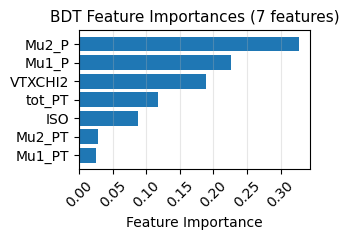

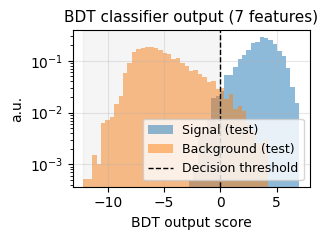

In [9]:
# now train a BDT using all features except MASS, which is the most powerful single feature and would dominate the classifier, preventing it from learning from the others
bdt_features_7 = [f for f in features if f != 'MASS']

# train the BDT on the 7 features
bdt_7 = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=SEED)
bdt_7.fit(X_train[bdt_features_7], y_train)

# accuracy on training and test sets for the 7-feature BDT
acc_train_7 = accuracy_score(y_train, bdt_7.predict(X_train[bdt_features_7]))
acc_7 = accuracy_score(y_test, bdt_7.predict(X_test[bdt_features_7]))

print(f"BDT 7-feat train acc: {acc_train_7:.4f}")
print(f"BDT 7-feat test acc:  {acc_7:.4f}")
print(f"BDT 3-feat test acc:  {acc_3:.4f}")
print(f"Again train ~ test, no overfitting.")

# feature importances tell us how much each feature contributed to the BDT decisions
importances = bdt_7.feature_importances_
sorted_idx = np.argsort(importances) # ascending order so the top feature ends up at the top of the bar chart

# plot the importances
fig, ax = plt.subplots(figsize=(3.3, 2.5))
ax.barh(np.array(bdt_features_7)[sorted_idx], importances[sorted_idx])
ax.set_xlabel('Feature Importance')
ax.set_title('BDT Feature Importances (7 features)')
ax.grid(True, alpha=0.3, axis='x')
ax.set_xticks(np.arange(0, 0.35, 0.05))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('plots/bdt_importances.png', dpi=200, bbox_inches='tight')
plt.show()

# BDT score distribution to see how well signal and background separate
scores_sig = bdt_7.decision_function(X_test[bdt_features_7][y_test == 1])
scores_bkg = bdt_7.decision_function(X_test[bdt_features_7][y_test == 0])

# plot score distributions for signal and background on the same axes
fig, ax = plt.subplots(figsize=(3.3, 2.5))
lo_s = min(scores_sig.min(), scores_bkg.min()) # lower edge from the smallest score in either class
hi_s = max(scores_sig.max(), scores_bkg.max()) # upper edge from the largest score
bins_score = np.linspace(lo_s, hi_s, 50) # same bins for both so the histograms are directly comparable

ax.hist(scores_sig, bins=bins_score, density=True, histtype='stepfilled',
        alpha=0.5, label='Signal (test)')
ax.hist(scores_bkg, bins=bins_score, density=True, histtype='stepfilled',
        alpha=0.5, label='Background (test)')
ax.set_xlabel('BDT output score')
ax.set_ylabel('a.u.') # arbitrary units, normalized histograms
ax.set_title('BDT classifier output (7 features)')
ax.set_yscale('log')
# mark the decision threshold and shade the background-classified region
ax.axvline(0, color='k', linestyle='--', linewidth=1, label='Decision threshold')
ax.axvspan(lo_s, 0, color='gray', alpha=0.08)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/bdt_score_dist.png', dpi=200, bbox_inches='tight')
plt.show()

### 1f - Apply BDT selection

Apply the 7-feature BDT to both samples and measure signal and background efficiencies. Signal efficiency is the fraction of signal we keep, background efficiency is how much background leaks through. We want high signal efficiency and low background leakage.

We evaluate on the test set only, not the full dataset. The BDT was trained on the other half, so using all events would include training data and give us overly optimistic numbers (overfitting bias).

Signal efficiency:     0.9774 +/- 0.0021
Background efficiency: 0.0487 +/- 0.0031
Signal passing:     4920 / 5034
Background passing: 242 / 4966


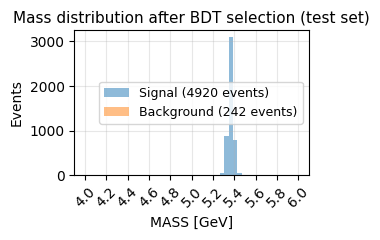

In [10]:
# evaluate on test set only to avoid overfitting bias
sig_test = X_test[y_test == 1] # signal events from the test set
bkg_test = X_test[y_test == 0] # background events from the test set

# apply the 7-feature BDT to the signal and background test sets
sig_pred = bdt_7.predict(sig_test[bdt_features_7])
bkg_pred = bdt_7.predict(bkg_test[bdt_features_7])

# signal and background efficiencies (fraction predicted as signal-like) on the test set
sig_eff = np.mean(sig_pred == 1)
bkg_eff = np.mean(bkg_pred == 1)

# binomial uncertainties (our addition, not required, just a useful check)
n_sig_test = len(sig_test) # number of signal events in the test set
n_bkg_test = len(bkg_test) # number of background events in the test set
sig_eff_err = np.sqrt(sig_eff * (1 - sig_eff) / n_sig_test)
bkg_eff_err = np.sqrt(bkg_eff * (1 - bkg_eff) / n_bkg_test)

# print efficiencies and the number of events passing the BDT selection
print(f"Signal efficiency:     {sig_eff:.4f} +/- {sig_eff_err:.4f}")
print(f"Background efficiency: {bkg_eff:.4f} +/- {bkg_eff_err:.4f}")
print(f"Signal passing:     {np.sum(sig_pred == 1)} / {n_sig_test}") # signal events predicted as signal-like
print(f"Background passing: {np.sum(bkg_pred == 1)} / {n_bkg_test}")

# now look at the mass distribution of the events that pass the BDT, to see whether a signal peak emerges from the background
sig_mass = sig_test.loc[sig_pred == 1, 'MASS'].values
bkg_mass = bkg_test.loc[bkg_pred == 1, 'MASS'].values

# plot the mass distribution after BDT selection for signal and background
fig, ax = plt.subplots(figsize=(3.3, 2.5))
bins = np.linspace(MASS_LO, MASS_HI, 50)
ax.hist(sig_mass, bins=bins, histtype='stepfilled',
        alpha=0.5, label=f'Signal ({len(sig_mass)} events)')
ax.hist(bkg_mass, bins=bins, histtype='stepfilled',
        alpha=0.5, label=f'Background ({len(bkg_mass)} events)')
ax.set_xlabel('MASS [GeV]')
ax.set_ylabel('Events')
ax.set_title('Mass distribution after BDT selection (test set)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(np.arange(4, 6.2, 0.2))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('plots/mass_after_bdt.png', dpi=200, bbox_inches='tight')
plt.show()

## Part 2: Experiment Duration (Section 4)

### 2a - Composite PDF and toy generation

We fit the background mass shape from the full background sample (all 10k events), then build a composite model to generate toy experiments. The assignment says to establish the exponential on the background.txt sample. We minimize the negative log-likelihood (NLL) to find the best-fit lambda.

- Signal: Gaussian(mu=5, sigma=0.03) GeV
- Background: Exponential in [4.0, 6.0] GeV
- Signal rate after BDT: 50/year times signal efficiency
- Background rate after BDT: 2000/year times background efficiency

Fitted lambda = 0.0283


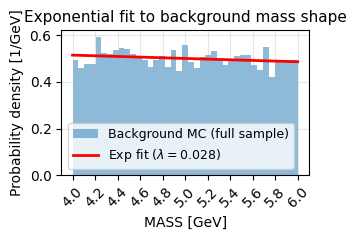


Expected events per year:
  Signal:     48.9
  Background: 97.5


In [11]:
def exp_nll(lam, data):
    """Negative log-likelihood for an exponential distribution with parameter lambda, normalized to the range [MASS_LO, MASS_HI]."""
    # the PDF of an exponential is f(x) = lam * exp(-lam * x), but we need to normalize it to the range [MASS_LO, MASS_HI] since our data is only in that range
    Z = (np.exp(-lam * MASS_LO) - np.exp(-lam * MASS_HI)) / lam
    # return the negative log-likelihood, which is -sum(log(f(x_i))) for all data points x_i
    return -np.sum(-lam * data) + len(data) * np.log(Z)

# fit lambda from the full background sample (not just post-BDT)
bkg_mass = bkg['MASS'].values
fit_result = optimize.minimize_scalar(lambda slope: exp_nll(slope, bkg_mass), bounds=(-5, 5), method='bounded')
lambda_fit = fit_result.x

print(f"Fitted lambda = {lambda_fit:.4f}")

# plot the background mass distribution and the fitted exponential to visualize the fit quality
fig, ax = plt.subplots(figsize=(3.3, 2.5))
bins = np.linspace(MASS_LO, MASS_HI, 40)
ax.hist(bkg_mass, bins=bins, density=True, histtype='stepfilled',
        alpha=0.5, label='Background MC (full sample)')
m_plot = np.linspace(MASS_LO, MASS_HI, 200)
Z = (np.exp(-lambda_fit * MASS_LO) - np.exp(-lambda_fit * MASS_HI)) / lambda_fit
ax.plot(m_plot, np.exp(-lambda_fit * m_plot) / Z, 'r-', lw=2, label=f'Exp fit ($\\lambda={lambda_fit:.3f}$)')
ax.set_xlabel('MASS [GeV]')
ax.set_ylabel('Probability density [1/GeV]')
ax.set_title('Exponential fit to background mass shape')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(np.arange(4, 6.2, 0.2))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('plots/exp_fit.png', dpi=200, bbox_inches='tight')
plt.show()

# expected signal and background events per year after the BDT selection
n_sig_per_year = N_SIG_PER_YEAR * sig_eff
n_bkg_per_year = N_BKG_PER_YEAR * bkg_eff
print(f"\nExpected events per year:")
print(f"  Signal:     {n_sig_per_year:.1f}")
print(f"  Background: {n_bkg_per_year:.1f}")

We generate 1000 toy datasets for 1 year of running. For each toy we Poisson-fluctuate the event counts and sample masses from the PDFs above.

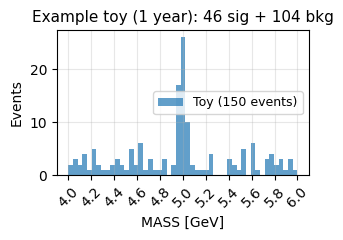

In [12]:
def sample_truncated_exp(lam, lo, hi, size):
    """Sample from a truncated exponential distribution with parameter lambda, truncated to the range [lo, hi]."""
    # generate uniform random numbers between 0 and 1
    u = np.random.uniform(0, 1, size)
    # CDF terms of the exponential at the lower and upper bounds
    c_lo = np.exp(-lam * lo)
    c_hi = np.exp(-lam * hi)
    # inverse CDF sampling for a truncated exponential distribution
    return -np.log(c_lo - u * (c_lo - c_hi)) / lam

def sample_truncated_gauss(mu, sigma, lo, hi, size):
    """Sample from a truncated Gaussian distribution with parameters mu and sigma, truncated to the range [lo, hi]."""
    # inverse CDF sampling on the truncated Gaussian
    u = np.random.uniform(0, 1, size)
    c_lo = norm.cdf(lo, mu, sigma)
    c_hi = norm.cdf(hi, mu, sigma)
    return norm.ppf(c_lo + u * (c_hi - c_lo), mu, sigma)

def generate_toy(mu_sig, mu_bkg, lam):
    """Generate a toy dataset with signal and background events."""
    # sample the number of signal and background events from Poisson distributions
    n_sig_sampled = np.random.poisson(mu_sig)
    n_bkg_sampled = np.random.poisson(mu_bkg)
    # sample signal masses from a truncated Gaussian
    m_s = sample_truncated_gauss(MU, SIGMA, MASS_LO, MASS_HI, n_sig_sampled)
    # sample background masses from a truncated exponential
    m_b = sample_truncated_exp(lam, MASS_LO, MASS_HI, n_bkg_sampled)
    # combine and shuffle so signal/background are mixed
    m_toy = np.concatenate([m_s, m_b])
    np.random.shuffle(m_toy)
    # return masses and the sampled yields
    return m_toy, n_sig_sampled, n_bkg_sampled

# generate one toy for 1 year as a check
np.random.seed(SEED)
m_toy, n_sig_sampled, n_bkg_sampled = generate_toy(
    n_sig_per_year, n_bkg_per_year, lambda_fit
)

# plot the mass distribution of the toy to see whether a signal peak shows up over the background
fig, ax = plt.subplots(figsize=(3.3, 2.5))
bins = np.linspace(MASS_LO, MASS_HI, 50)
ax.hist(m_toy, bins=bins, histtype='stepfilled', alpha=0.7,
        label=f'Toy ({len(m_toy)} events)')
ax.set_xlabel('MASS [GeV]')
ax.set_ylabel('Events')
ax.set_title(f'Example toy (1 year): {n_sig_sampled} sig + {n_bkg_sampled} bkg')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(np.arange(4, 6.2, 0.2))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('plots/toy_example.png', dpi=200, bbox_inches='tight')
plt.show()


### 2b - Fit toys and signal fraction

For each toy we fit a composite model: $f(m) = f_\text{sig} \cdot f_s(m) + (1 - f_\text{sig}) \cdot f_b(m)$, where $f_\text{sig}$ is the signal fraction. We compare a signal+background fit (free params: $f_\text{sig}$, $\lambda$) against a background-only fit (free param: $\lambda$). Gaussian mean and width are fixed from the known signal properties.

True f_sig: 0.3340
Mean fitted f_sig: 0.3348 +/- 0.0434
Mean H1 lambda: 0.0239 +/- 0.1790
Background-only lambda (full sample): 0.0283
Fraction of toys with f_sig pinned at 0: 0.000
Std of one-year significances: 1.29 sigma


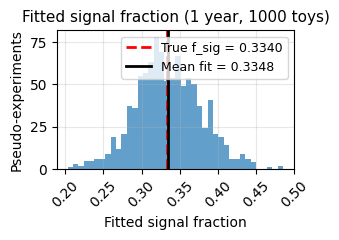

In [13]:
def gauss_pdf(m):
    """PDF of a Gaussian distribution with mean MU and standard deviation SIGMA, normalized to the range [MASS_LO, MASS_HI]."""
    # normalization constant for the truncated Gaussian
    Z = norm.cdf(MASS_HI, MU, SIGMA) - norm.cdf(MASS_LO, MU, SIGMA)
    # value of the truncated Gaussian PDF
    return norm.pdf(m, MU, SIGMA) / Z

def exp_pdf(m, lam):
    """PDF of an exponential distribution with parameter lambda, normalized to the range [MASS_LO, MASS_HI]."""
    # normalization constant for the truncated exponential
    Z = (np.exp(-lam * MASS_LO) - np.exp(-lam * MASS_HI)) / lam
    # value of the truncated exponential PDF
    return np.exp(-lam * m) / Z

def composite_nll(params, m_toy):
    """Negative log-likelihood for a composite model of signal + background, where the signal is a Gaussian and the background is an exponential."""
    # fs is the signal fraction in [0, 1], lam is the exponential slope
    fs, lam = params
    # PDF under the composite model (weighted sum of signal and background PDFs)
    pdf = fs * gauss_pdf(m_toy) + (1 - fs) * exp_pdf(m_toy, lam)
    # avoid log(0)
    pdf[pdf < 1e-300] = 1e-300 
    # return NLL
    return -np.sum(np.log(pdf))

def bkg_only_nll(params, m_toy):
    """Negative log-likelihood for the background-only model (exponential)."""
    # only parameter is lambda for the exponential background
    lam = params[0]
    pdf = exp_pdf(m_toy, lam)
    # avoid log(0)
    pdf[pdf < 1e-300] = 1e-300 
    # return NLL
    return -np.sum(np.log(pdf))

def fit_toy(m_toy):
    """Fit both the signal+background model and the background-only model to the toy data, and return fit results."""
    # fit signal+background model
    res_sb = optimize.minimize(
        composite_nll, x0=[0.1, lambda_fit], args=(m_toy,),
        bounds=[(0, 1), (-10, 10)], method='L-BFGS-B'
    )
    fs_hat, lam_hat = res_sb.x
    nll_sb = res_sb.fun

    # fit background-only model
    res_b = optimize.minimize(
        bkg_only_nll, x0=[lambda_fit], args=(m_toy,),
        bounds=[(-10, 10)], method='L-BFGS-B'
    )
    nll_b = res_b.fun

    return fs_hat, lam_hat, nll_sb, nll_b

# run 1000 toys for 1 year
np.random.seed(SEED) # random seed for reproducibility
n_toys = 1000 # number of pseudo-experiments (toys) to run
fs_list = [] # fitted signal fraction from each toy
Z_list = [] # significance from each toy
lam_list = [] # fitted lambda under H1

# loop over toys
for _ in range(n_toys):
    # generate a toy dataset for 1 year
    m_toy, _, _ = generate_toy(
        n_sig_per_year, n_bkg_per_year, lambda_fit
    )
    # fit the toy with both models
    fs_hat, lam_hat, nll_sb, nll_b = fit_toy(m_toy)
    # store the fitted signal fraction
    fs_list.append(fs_hat)
    lam_list.append(lam_hat)
    # test statistic q for this toy
    q = 2 * (nll_b - nll_sb)
    # ensure q is non-negative
    q = max(q, 0)
    # compute and store significance
    Z_list.append(np.sqrt(q))

# convert lists to numpy arrays for easier analysis and plotting
fs_list = np.array(fs_list)
Z_list = np.array(Z_list)
lam_list = np.array(lam_list)
# true signal fraction
fs_true = n_sig_per_year / (n_sig_per_year + n_bkg_per_year)

print(f"True f_sig: {fs_true:.4f}")
print(f"Mean fitted f_sig: {np.mean(fs_list):.4f} +/- {np.std(fs_list):.4f}")
print(f"Mean H1 lambda: {np.mean(lam_list):.4f} +/- {np.std(lam_list):.4f}")
print(f"Background-only lambda (full sample): {lambda_fit:.4f}")
frac_at_zero = float(np.mean(fs_list <= 1e-6))
print(f"Fraction of toys with f_sig pinned at 0: {frac_at_zero:.3f}")
print(f"Std of one-year significances: {np.std(Z_list):.2f} sigma")

# plot the distribution of fitted signal fractions
fig, ax = plt.subplots(figsize=(3.3, 2.5))
ax.hist(fs_list, bins=40, alpha=0.7)
ax.axvline(fs_true, color='r', ls='--', lw=2, label=f'True f_sig = {fs_true:.4f}')
ax.axvline(np.mean(fs_list), color='k', ls='-', lw=2, label=f'Mean fit = {np.mean(fs_list):.4f}')
ax.set_xlabel('Fitted signal fraction')
ax.set_ylabel('Pseudo-experiments')
ax.set_title('Fitted signal fraction (1 year, 1000 toys)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(np.arange(0.2, 0.51, 0.05))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('plots/fsig_distribution.png', dpi=200, bbox_inches='tight')
plt.show()


The mean fitted signal fraction matches the true value, so the fit is unbiased.

### 2c - Significance distribution

Using Wilks' theorem: $q = 2(\text{NLL}_{\text{bkg}} - \text{NLL}_{s+b})$ follows $\chi^2(1)$ under the null hypothesis. Significance in sigma is $\sqrt{q}$.

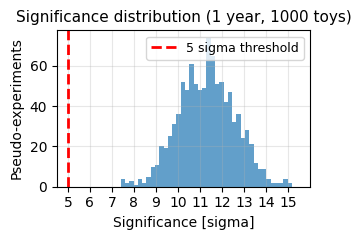

Mean significance: 11.31 sigma
Median significance: 11.33 sigma
Fraction >5 sigma: 1.000


In [14]:
# fraction of toys that exceed 5 sigma significance (typical discovery threshold)
frac_above_5 = np.mean(Z_list > 5)

# plot the distribution of significances and indicate the 5 sigma threshold
fig, ax = plt.subplots(figsize=(3.3, 2.5))
ax.hist(Z_list, bins=40, alpha=0.7)
ax.axvline(5.0, color='r', ls='--', lw=2, label='5 sigma threshold')
ax.set_xlabel('Significance [sigma]')
ax.set_ylabel('Pseudo-experiments')
ax.set_xlim(4.5, 16)
ax.set_xticks(np.arange(5, 16))
ax.set_title(f'Significance distribution (1 year, {n_toys} toys)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/significance_dist.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Mean significance: {np.mean(Z_list):.2f} sigma")
print(f"Median significance: {np.median(Z_list):.2f} sigma")
print(f"Fraction >5 sigma: {frac_above_5:.3f}")

### 2d - Required experiment duration

We repeat the toy study for different run durations (scaling event counts linearly with time) and find when 95% of toys exceed 5 sigma.

   1.0 months: 0.071
   1.1 months: 0.098
   1.2 months: 0.128
   1.3 months: 0.148
   1.4 months: 0.202
   1.5 months: 0.199
   1.6 months: 0.245
   1.7 months: 0.273
   1.8 months: 0.293
   1.9 months: 0.317
   2.0 months: 0.385
   2.1 months: 0.435
   2.2 months: 0.496
   2.3 months: 0.495
   2.4 months: 0.524
   2.5 months: 0.573
   2.6 months: 0.565
   2.7 months: 0.607
   2.8 months: 0.634
   2.9 months: 0.659
   3.0 months: 0.709
   3.1 months: 0.733
   3.2 months: 0.737
   3.3 months: 0.749
   3.4 months: 0.786
   3.5 months: 0.787
   3.6 months: 0.838
   3.7 months: 0.805
   3.8 months: 0.850
   3.9 months: 0.875
   4.0 months: 0.881
   4.1 months: 0.908
   4.2 months: 0.909
   4.3 months: 0.913
   4.4 months: 0.910
   4.5 months: 0.916
   4.6 months: 0.932
   4.7 months: 0.951
   4.8 months: 0.952
   4.9 months: 0.947
   5.0 months: 0.961
   5.1 months: 0.960
   5.2 months: 0.969
   5.3 months: 0.979
   5.4 months: 0.976
   5.5 months: 0.980
   5.6 months: 0.978
   5.7 months

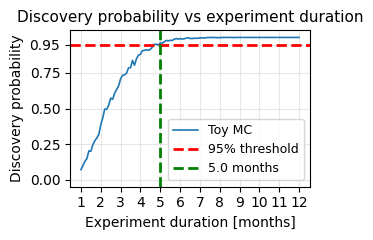

In [15]:
# range of experiment durations to scan (in months)
months_to_scan = np.arange(1.0, 12.05, 0.1).round(1) # 0.1-month grid from 1.0 to 12.0 months
# number of toys to run for each duration
n_toys_per_duration = 1000
# list to store discovery probability for each duration
probs = []

np.random.seed(SEED) # random seed for reproducibility
# loop over the experiment durations we want to scan
for T_months in months_to_scan:
    T_years = T_months / 12.0
    # expected signal and background events for this duration
    mu_sig = n_sig_per_year * T_years
    mu_bkg = n_bkg_per_year * T_years

    # counter for how many toys exceed 5 sigma at this duration
    n_pass = 0
    # run the specified number of toys for this duration
    for _ in range(n_toys_per_duration):
        # generate a toy dataset for this duration
        m_toy, _, _ = generate_toy(mu_sig, mu_bkg, lambda_fit)
        # fit the toy with both models
        _, _, nll_sb, nll_b = fit_toy(m_toy)
        # test statistic q (clipped at 0)
        q = max(2 * (nll_b - nll_sb), 0)
        if np.sqrt(q) > 5:
            n_pass += 1

    # fraction of toys that exceed 5 sigma at this duration
    p = n_pass / n_toys_per_duration
    probs.append(p)
    print(f"  {T_months:4.1f} months: {p:.3f}")

# convert discovery fractions to a numpy array for easier analysis and plotting
probs = np.array(probs)

# find the first month where probability stays >= 95% from then on
above_95 = probs >= 0.95
bad = np.where(~above_95)[0]
t95_idx = bad[-1] + 1 if len(bad) else 0
t95_months = float(months_to_scan[t95_idx])

# also report the very first crossing as the lower edge of the uncertainty band
good = np.where(above_95)[0]
t95_first = float(months_to_scan[good[0]])

print(f"\nFirst crossing of 95% (lower edge of uncertainty band): {t95_first:.1f} months")
print(f"Sustained 95% from (conservative answer): {t95_months:.1f} months")

# plot discovery probability vs experiment duration
fig, ax = plt.subplots(figsize=(3.3, 2.5))
ax.plot(months_to_scan, probs, '-', lw=1.2, label='Toy MC')
ax.axhline(0.95, color='r', ls='--', lw=2, label='95% threshold')
ax.axvline(t95_months, color='g', ls='--', lw=2, label=f'{t95_months:.1f} months')
ax.set_xlabel('Experiment duration [months]')
ax.set_ylabel('Discovery probability')
ax.set_xticks(np.arange(1, 13))
ax.set_yticks([0.0, 0.25, 0.5, 0.75, 0.95])
ax.set_title('Discovery probability vs experiment duration')
ax.legend()
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/discovery_duration.png', dpi=200, bbox_inches='tight')
plt.show()

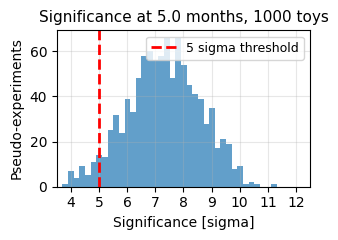

At 5.0 months:
  Mean significance:   7.28 sigma
  Median significance: 7.31 sigma
  Std of significances: 1.30 sigma
  Fraction > 5 sigma:  0.954


In [16]:
# extra plot at the discovery duration (our addition). At 1 year we're far above 5 sigma, so a histogram at t95 is more informative.
T_thr = t95_months
T_thr_years = T_thr / 12.0
mu_sig = n_sig_per_year * T_thr_years
mu_bkg = n_bkg_per_year * T_thr_years

np.random.seed(SEED)
Z_thr = []
for _ in range(n_toys):
    m_toy, _, _ = generate_toy(
        mu_sig, mu_bkg, lambda_fit
    )
    _, _, nll_sb, nll_b = fit_toy(m_toy)
    q = max(2 * (nll_b - nll_sb), 0)
    Z_thr.append(np.sqrt(q))
Z_thr = np.array(Z_thr)

fig, ax = plt.subplots(figsize=(3.3, 2.5))
ax.hist(Z_thr, bins=40, alpha=0.7)
ax.axvline(5.0, color='r', ls='--', lw=2, label='5 sigma threshold')
ax.set_xlabel('Significance [sigma]')
ax.set_ylabel('Pseudo-experiments')
ax.set_xlim(3.5, 12.5)
ax.set_xticks(np.arange(4, 13))
ax.set_title(f'Significance at {T_thr:.1f} months, {n_toys} toys')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/significance_dist_threshold.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"At {T_thr:.1f} months:")
print(f"  Mean significance:   {np.mean(Z_thr):.2f} sigma")
print(f"  Median significance: {np.median(Z_thr):.2f} sigma")
print(f"  Std of significances: {np.std(Z_thr):.2f} sigma")
print(f"  Fraction > 5 sigma:  {np.mean(Z_thr > 5):.3f}")

## Summary

The 7-feature BDT reaches *96.44% test accuracy* and train/test agreement is still good, so overfitting is under control. We evaluate efficiencies on the test set only (as required) and get *signal efficiency = 0.9774 +/- 0.0021* and *background efficiency = 0.0487 +/- 0.0031*.

With these efficiencies, the 1-year toy study gives a mean significance of *11.31 sigma*, and *100.0%* of toys exceed 5 sigma. Scanning the run duration on a 0.1-month grid, the discovery probability first crosses 95% at *4.7 months* but dips back to 94.7% at 4.9 months due to per-grid binomial noise of order 0.7%. From *5.0 months* onwards the probability stays at or above 95%, so we adopt 5.0 months as the conservative answer with 4.7 months as the lower edge of the uncertainty band.